# 02. Modelling: leaderboard, tuning and evaluation

Compare ten model families with repeated stratified cross-validation, tune the winner with Optuna, pick an operating threshold, and evaluate on a held-out split. We run the at-risk early-warning task live here (fast settings) and load the registered artefacts for all three tasks.

In [1]:
import sys, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Image, Markdown, display
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)

from edupulse.config import get_settings
S = get_settings()
print("EduPulse project root:", S.project_root)

EduPulse project root: C:\Users\WzA\Desktop\ZAIN\PAI


## 1. A single call trains everything
`run_pipeline` loads the data, engineers features, runs the leaderboard, tunes with Optuna, picks the threshold, evaluates, explains, audits fairness and registers the model.

In [2]:
from edupulse.config import Settings
from edupulse.models.registry import ModelRegistry
from edupulse.pipeline import run_pipeline
import tempfile
tmp = Path(tempfile.mkdtemp())
fast = S.model_copy(update=dict(models_dir=tmp/'models', figures_dir=tmp/'figures', reports_dir=tmp/'reports', processed_dir=tmp/'processed', cv_repeats=1, n_trials=15, n_jobs=1))
out = run_pipeline('at_risk', settings=fast, registry=ModelRegistry(fast.models_dir))
print(out.headline)

2026/09/12 11:37:49 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\WzA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


11:37:50 | INFO     | edupulse.data.loader | Loaded raw dataset StudentsPerformance.csv with shape (1000, 8)


11:37:50 | INFO     | edupulse.pipeline | Task at_risk: 800 train / 200 test rows, 5 features


11:37:51 | INFO     | edupulse.models.train | baseline_majority        roc_auc=0.5000 ± 0.0000 (0.3s)


11:37:51 | INFO     | edupulse.models.train | logistic_regression      roc_auc=0.7426 ± 0.0394 (0.3s)


...

11:38:06 | INFO     | edupulse.models.mitigation | Group thresholds on lunch: {'free/reduced': 0.567, 'standard': 0.341}


11:38:07 | INFO     | edupulse.pipeline | Hold-out metrics for at_risk: {'threshold': 0.4197, 'roc_auc': 0.6989, 'average_precision': 0.521, 'brier': 0.2217, 'log_loss': 0.6297, 'accuracy': 0.53, 'balanced_accuracy': 0.5922, 'precision': 0.3471, 'recall': 0.7368, 'f1': 0.4719, 'f2': 0.6017, 'positive_rate': 0.285, 'flagged_rate': 0.605}


Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


11:38:13 | INFO     | edupulse.models.registry | Saved at_risk model v20260912-063750 -> C:\Users\WzA\AppData\Local\Temp\tmph5soyeeb\models\at_risk\20260912-063750


ROC-AUC 0.699 · PR-AUC 0.521 · recall 0.737 @ thr 0.42


In [3]:
board = out.training.leaderboard
board[['rank','model','family','roc_auc_mean','roc_auc_std','average_precision_mean','recall_mean','fit_seconds']].style.background_gradient(subset=['roc_auc_mean'], cmap='Blues').format(precision=4)

,rank,model,family,roc_auc_mean,roc_auc_std,average_precision_mean,recall_mean,fit_seconds
0,1,logistic_regression,linear,0.7426,0.0394,0.5214,0.6669,0.0254
1,2,svm_rbf,kernel,0.7058,0.0367,0.4672,0.6670,0.1048
2,3,gradient_boosting,tree,0.7010,0.0364,0.4602,0.2935,0.1418
3,4,xgboost,tree,0.6888,0.0233,0.4412,0.3067,0.0998
4,5,lightgbm,tree,0.6748,0.0295,0.4332,0.5923,0.0916
5,6,hist_gradient_boosting,tree,0.6737,0.0318,0.4239,0.6139,0.2396
6,7,knn,neighbors,0.6450,0.0087,0.3894,0.3200,0.0173
7,8,random_forest,tree,0.6419,0.0149,0.4038,0.5789,0.5551
8,9,extra_trees,tree,0.6340,0.0146,0.3912,0.5615,0.4696
9,10,baseline_majority,dummy,0.5000,0.0000,0.2850,0.0000,0.0159


Linear and kernel models win on this task. With only five categorical inputs (about 17 one-hot columns) there is little non-linear structure for trees to learn, and they over-fit the small training set.

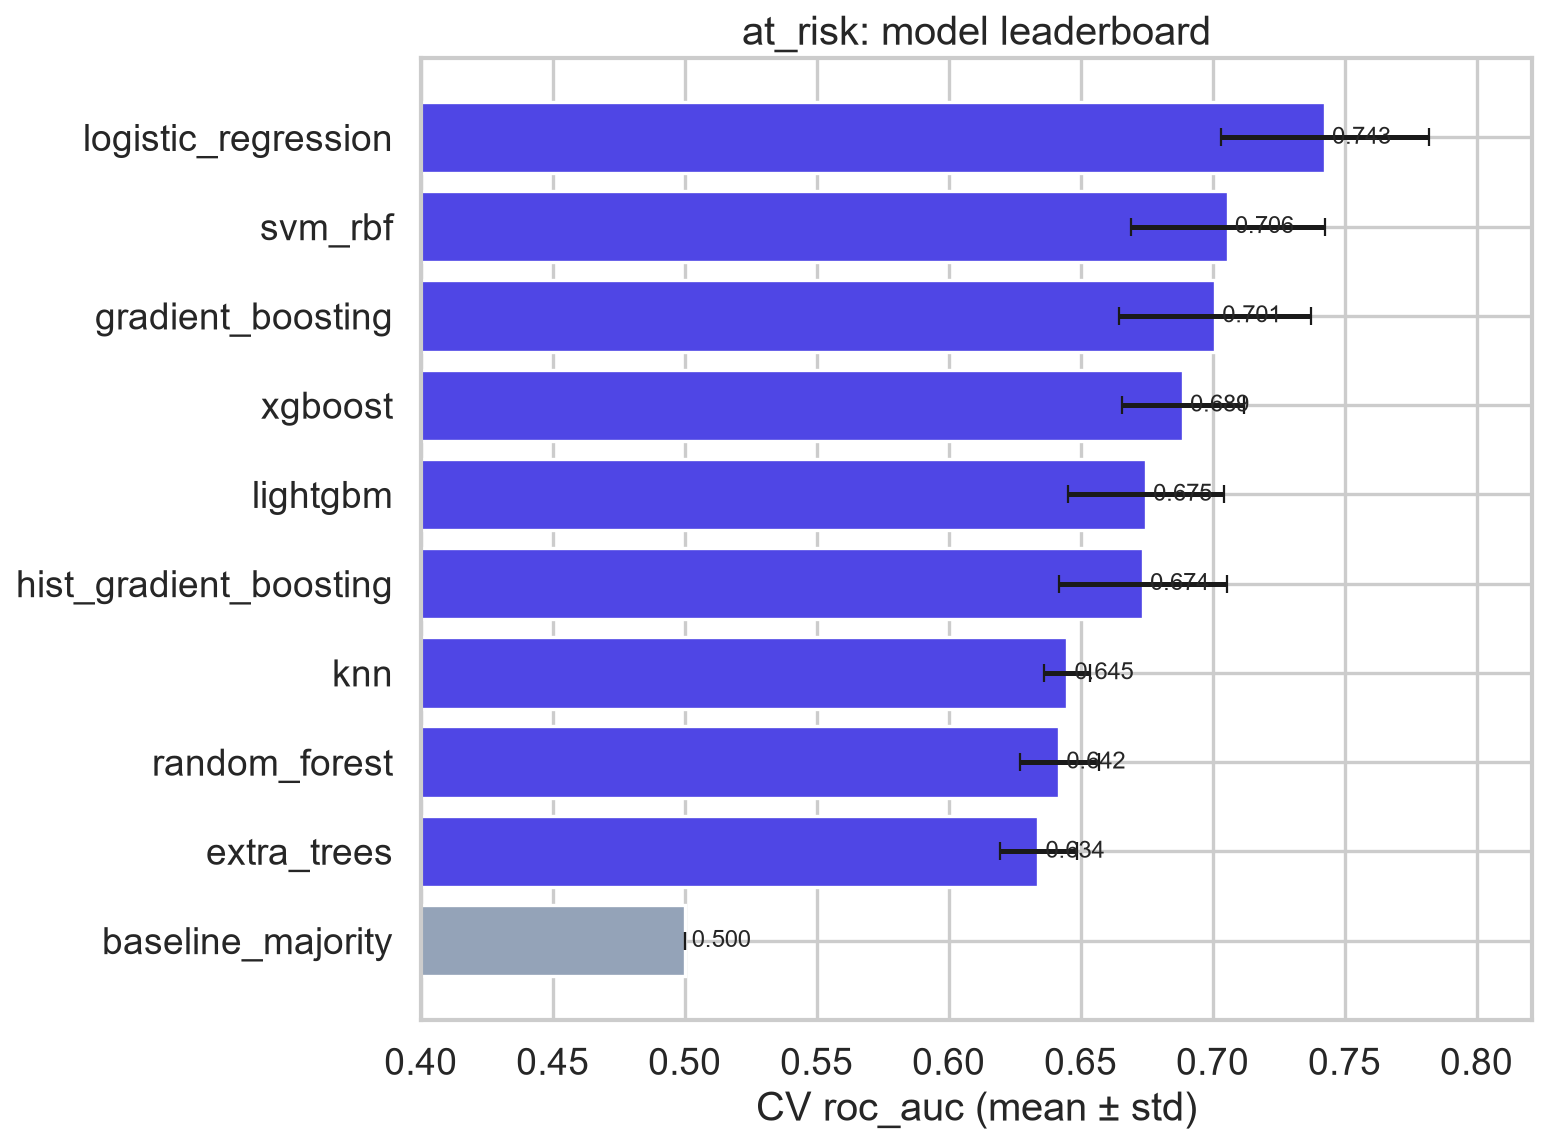

In [4]:
display(Image(str(fast.figures_dir/'at_risk'/'leaderboard.png')))

## 2. Hold-out evaluation

In [5]:
pd.Series({k: v for k, v in out.test_metrics.items() if isinstance(v, float)}).round(4).to_frame('hold-out')

,hold-out
threshold,0.4197
roc_auc,0.6989
average_precision,0.5210
brier,0.2217
log_loss,0.6297
accuracy,0.5300
balanced_accuracy,0.5922
precision,0.3471
recall,0.7368
f1,0.4719


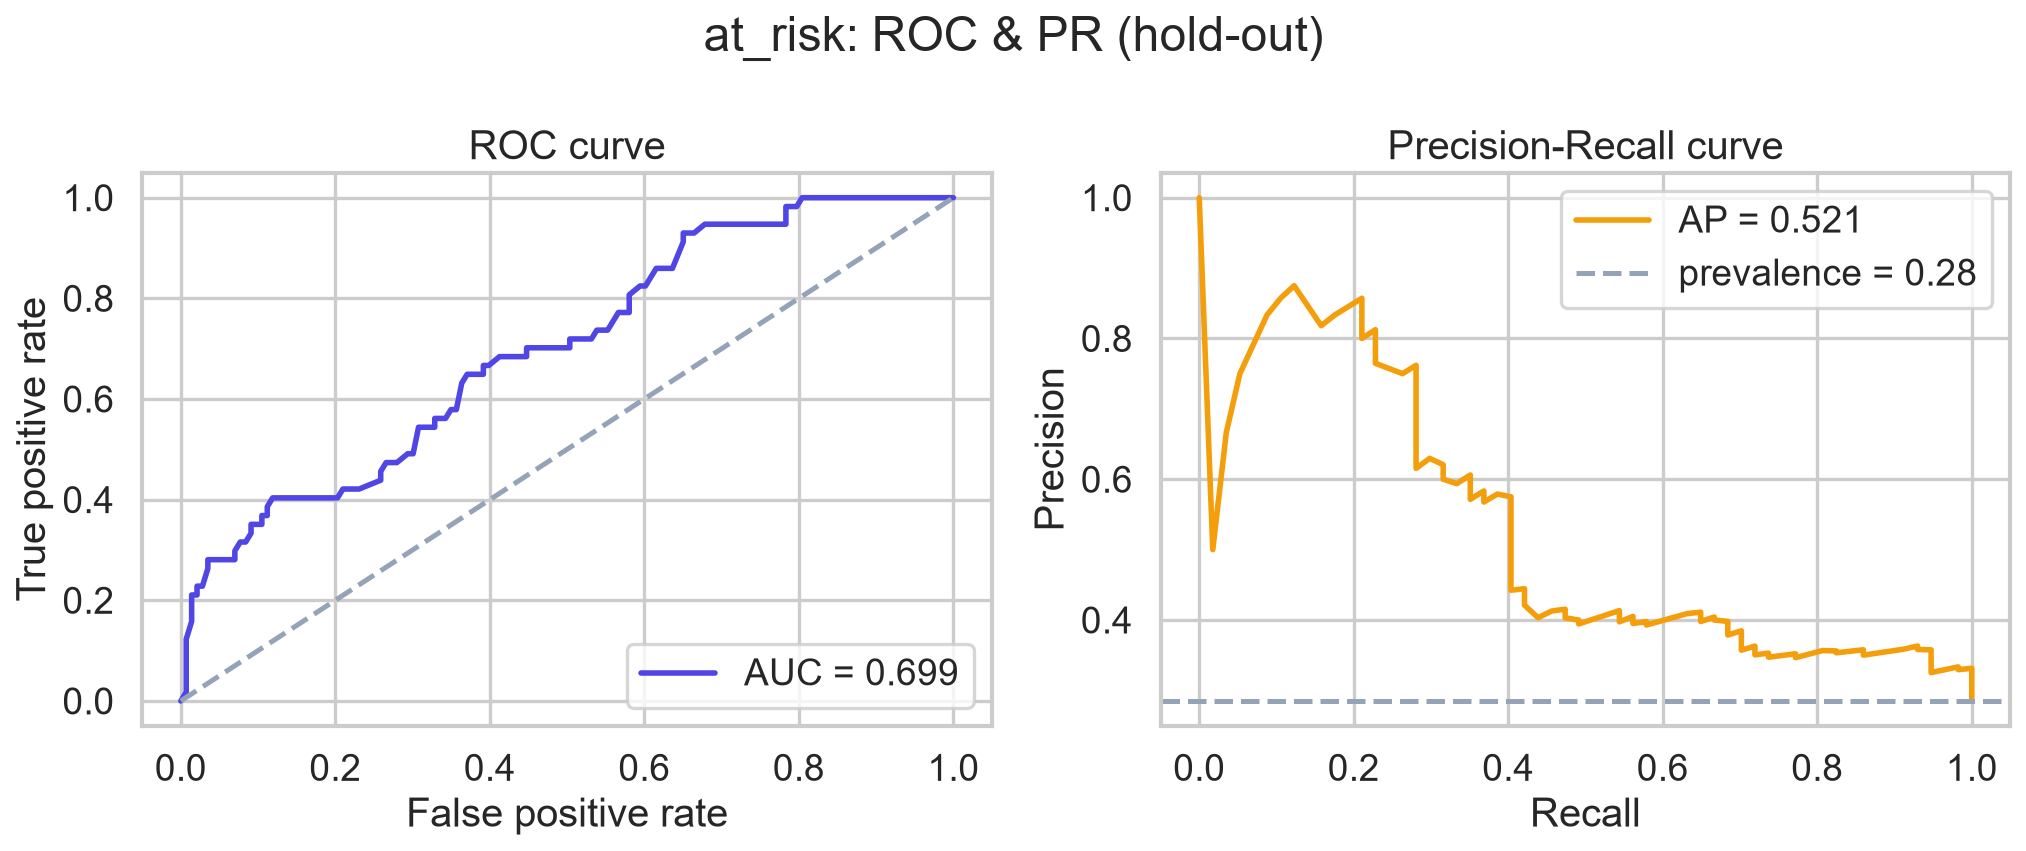

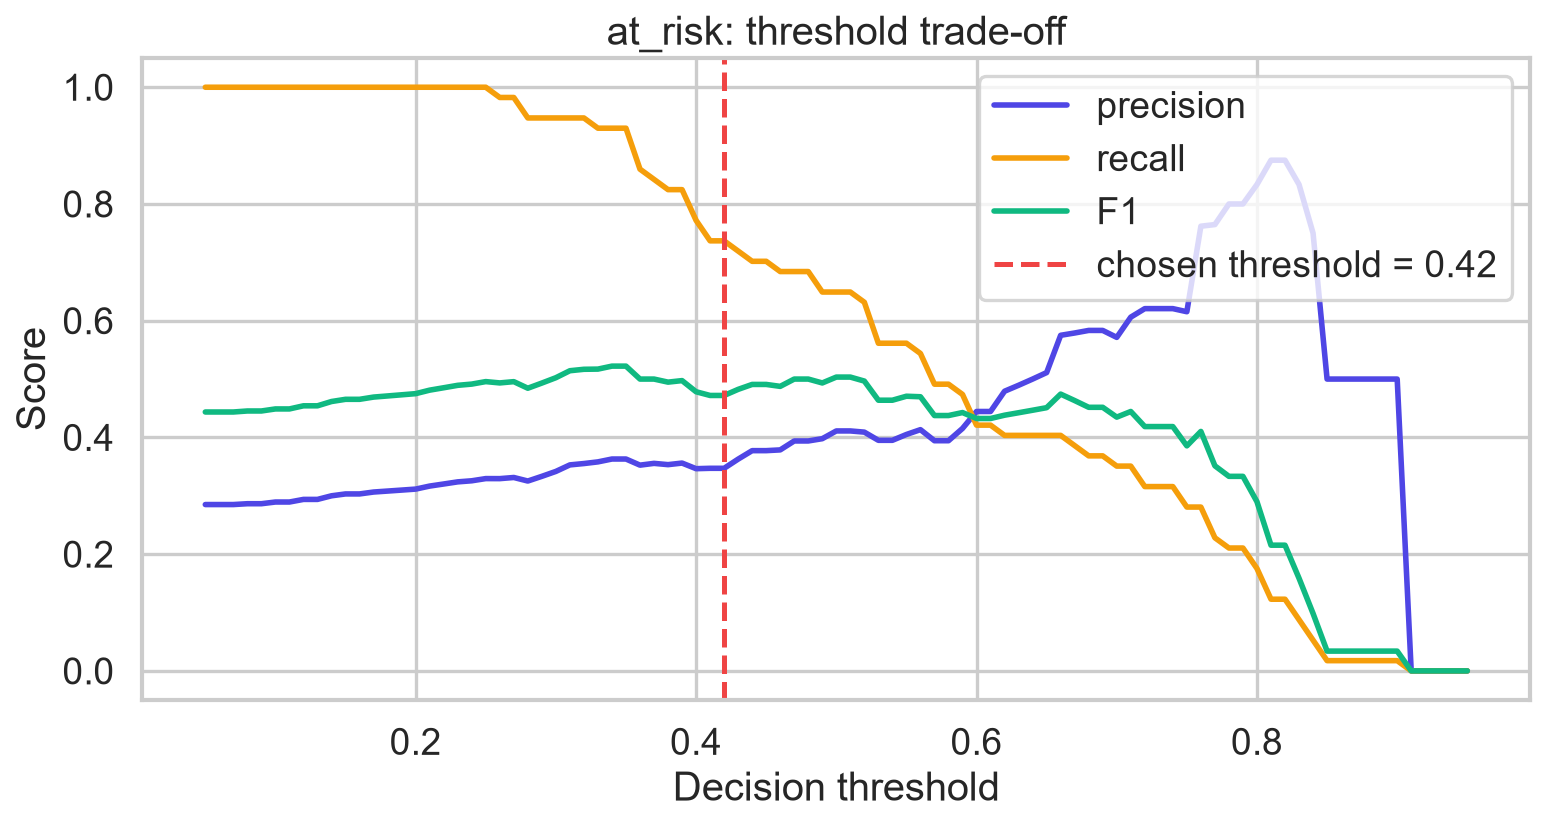

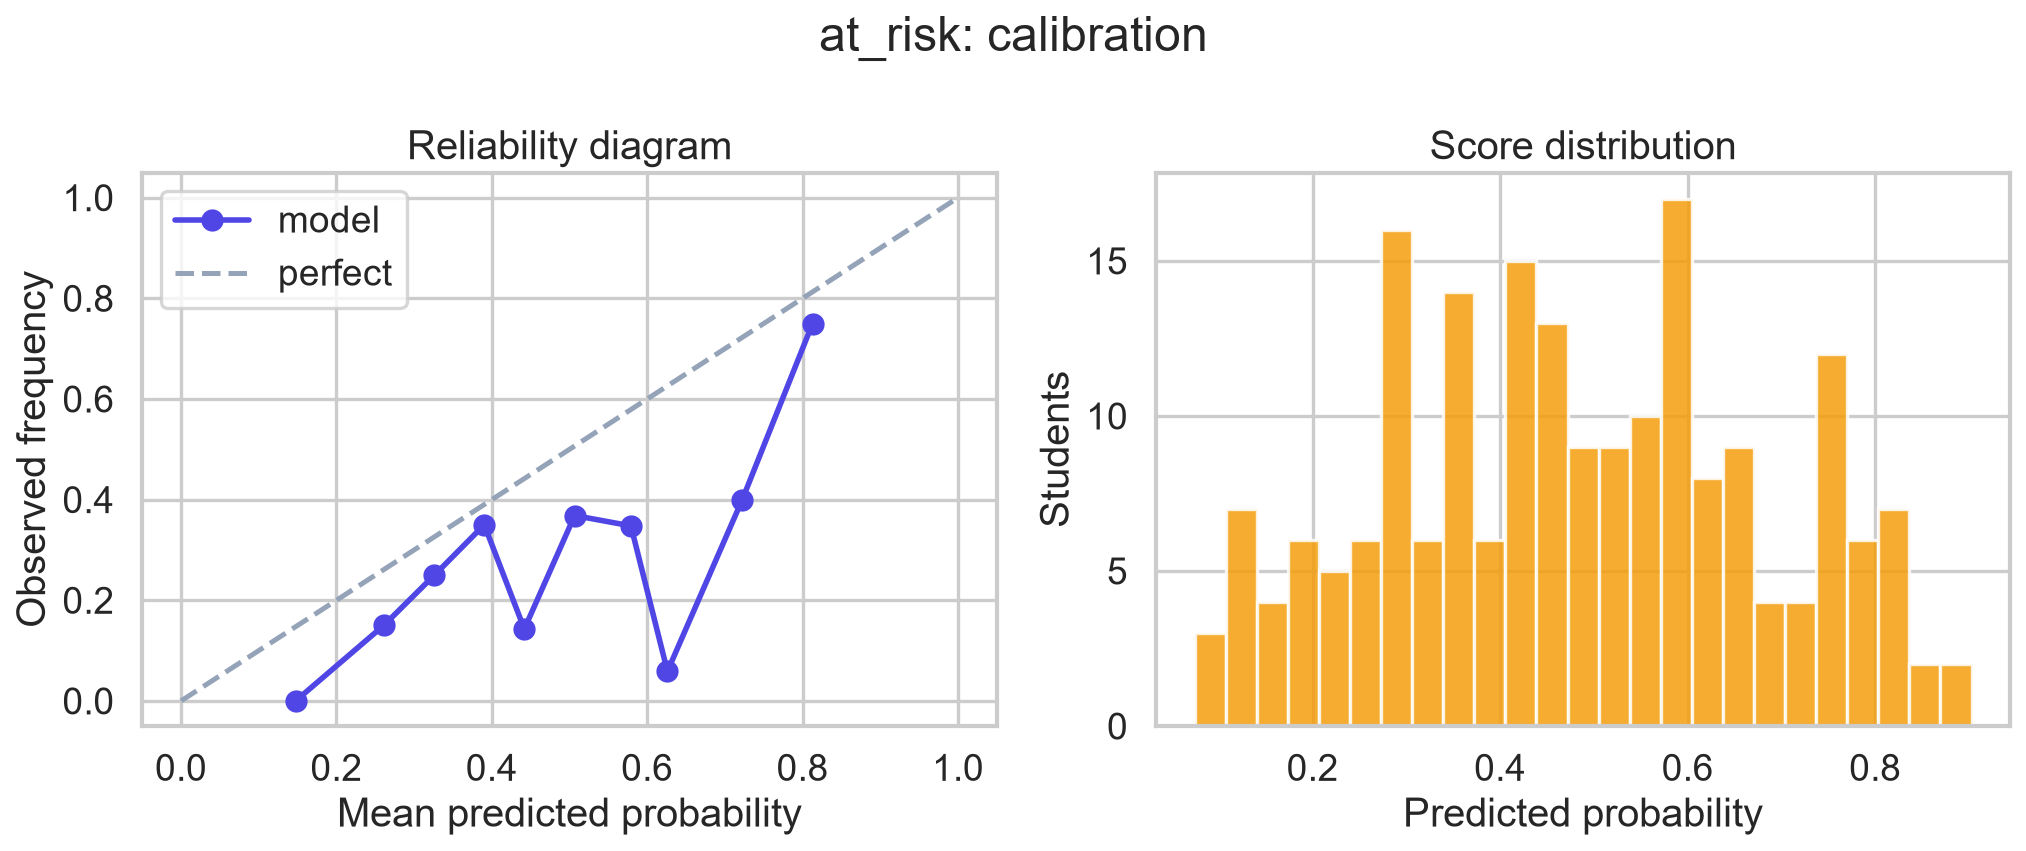

In [6]:
display(Image(str(fast.figures_dir/'at_risk'/'roc_pr.png')))
display(Image(str(fast.figures_dir/'at_risk'/'threshold_sweep.png')))
display(Image(str(fast.figures_dir/'at_risk'/'calibration.png')))

### Why not accuracy?
With a 28% positive rate, always predicting not-at-risk scores 71% accuracy. We select models on ROC-AUC and then choose the decision threshold as the most precise operating point that still recalls at least 80% of at-risk students on out-of-fold predictions. That is a policy statement an academic advisor can understand.

## 3. Registered models (full training run)
The artefacts under `models/` were produced by `edupulse train --all --trials 50`.

In [7]:
reg = ModelRegistry(S.models_dir)
rows = []
for t in ('at_risk','math_score','performance_level'):
    try:
        m = reg.load(t)
    except FileNotFoundError:
        continue
    md = m.metadata
    rows.append({'task': t, 'model': md.model_name, 'version': md.version, 'cv_metric': md.cv_metric, 'cv_score': round(md.cv_score, 4),
                 **{k: round(v, 4) for k, v in md.test_metrics.items() if k in ('roc_auc','average_precision','recall','precision','r2','rmse','mae','accuracy','f1_macro')}})
pd.DataFrame(rows).set_index('task')

,model,version,cv_metric,cv_score,roc_auc,average_precision,accuracy,precision,recall,r2,rmse,mae,f1_macro
task,,,,,,,,,,,,,
at_risk,logistic_regression,20260912-061545,roc_auc,0.7429,0.6986,0.5151,0.530,0.3471,0.7368,NaN,NaN,NaN,NaN
math_score,ridge,20260912-060202,r2,0.8676,NaN,NaN,NaN,NaN,NaN,0.8819,5.3616,4.179,NaN
performance_level,hist_gradient_boosting,20260912-054502,f1_macro,0.9708,NaN,NaN,0.985,NaN,NaN,NaN,NaN,NaN,0.9852


### at_risk: logistic_regression

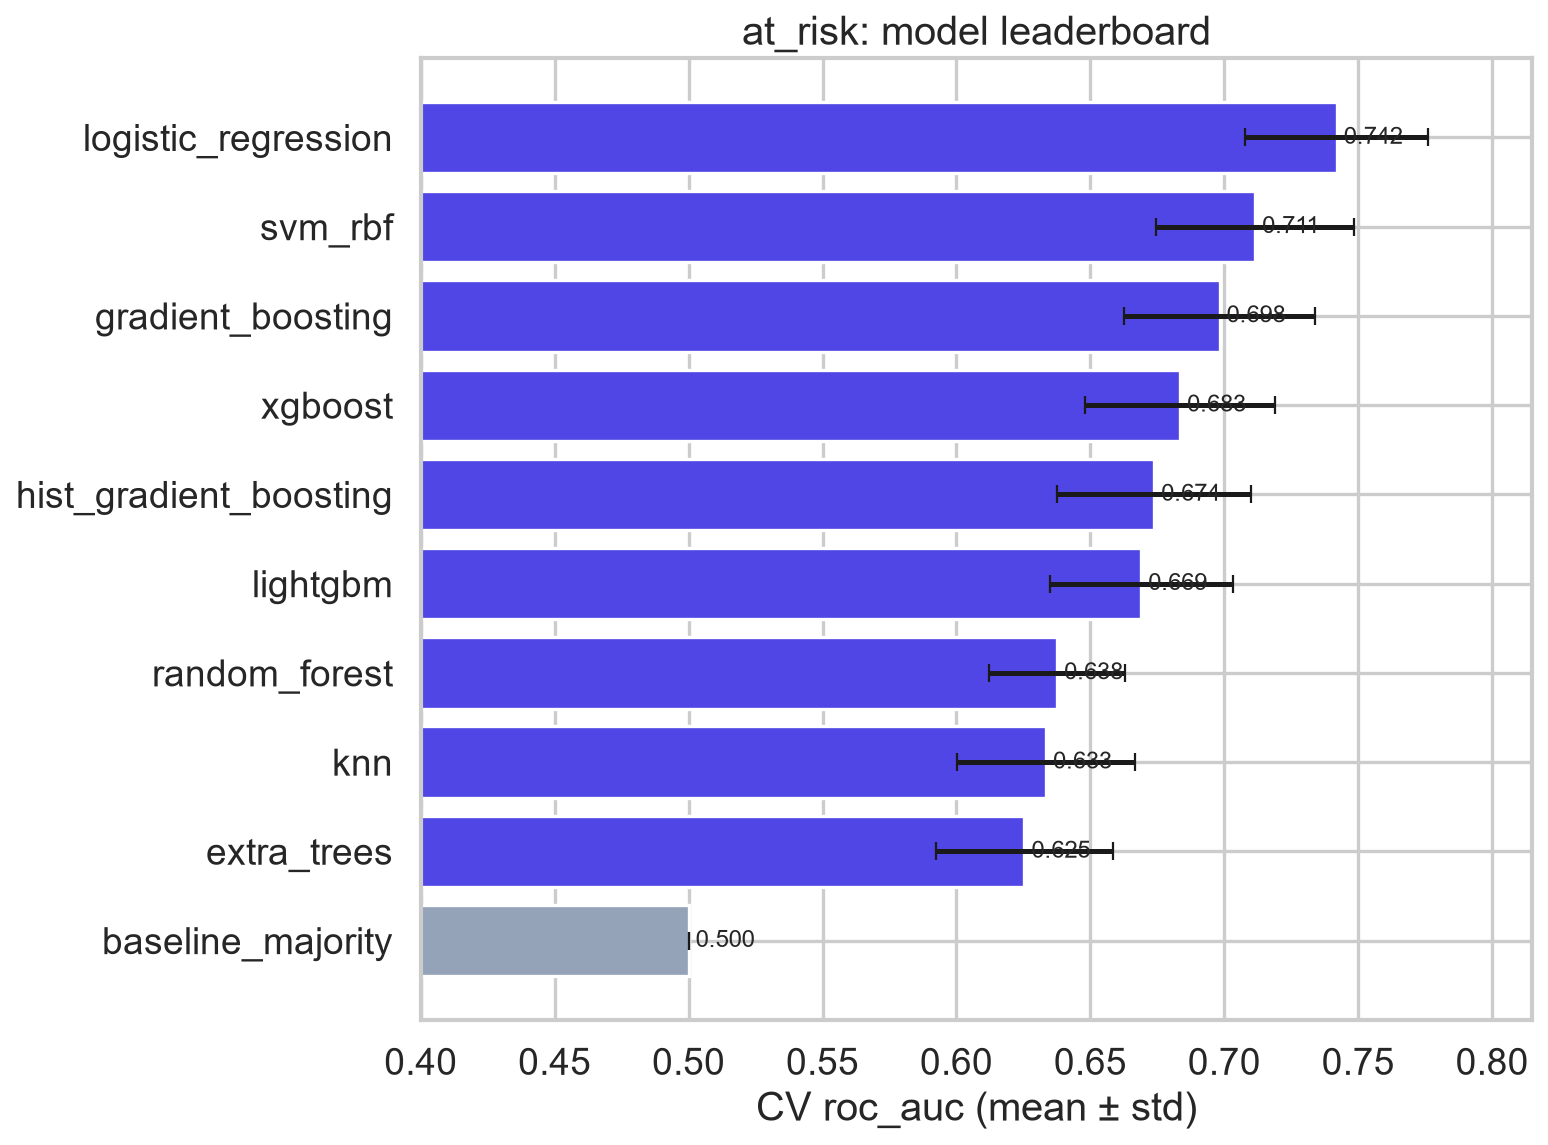

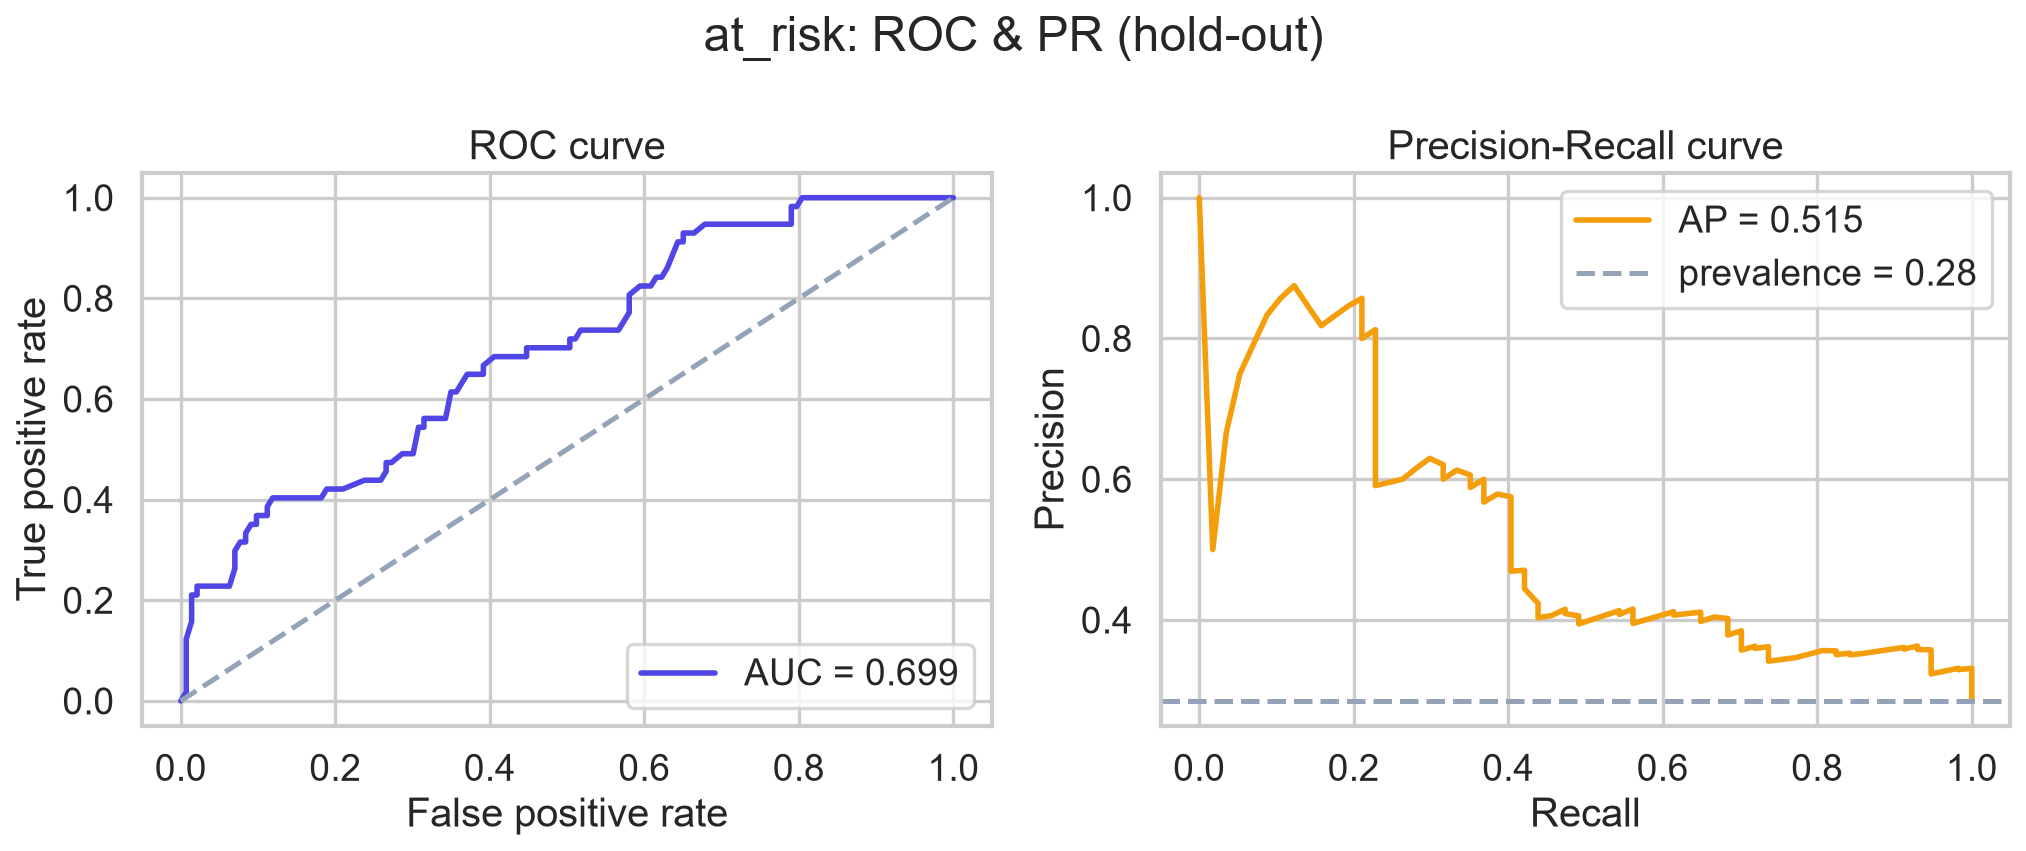

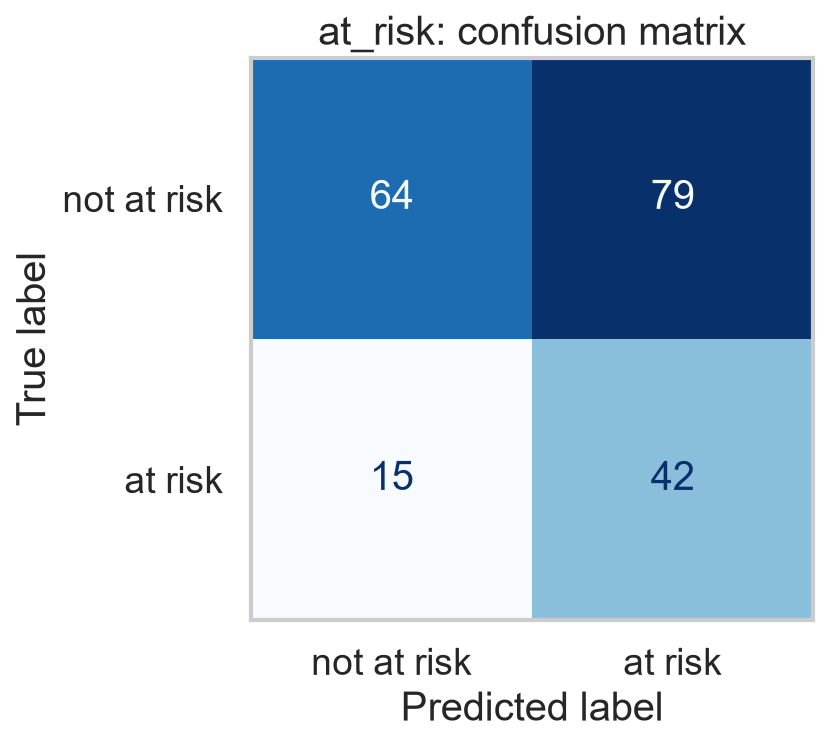

### math_score: ridge

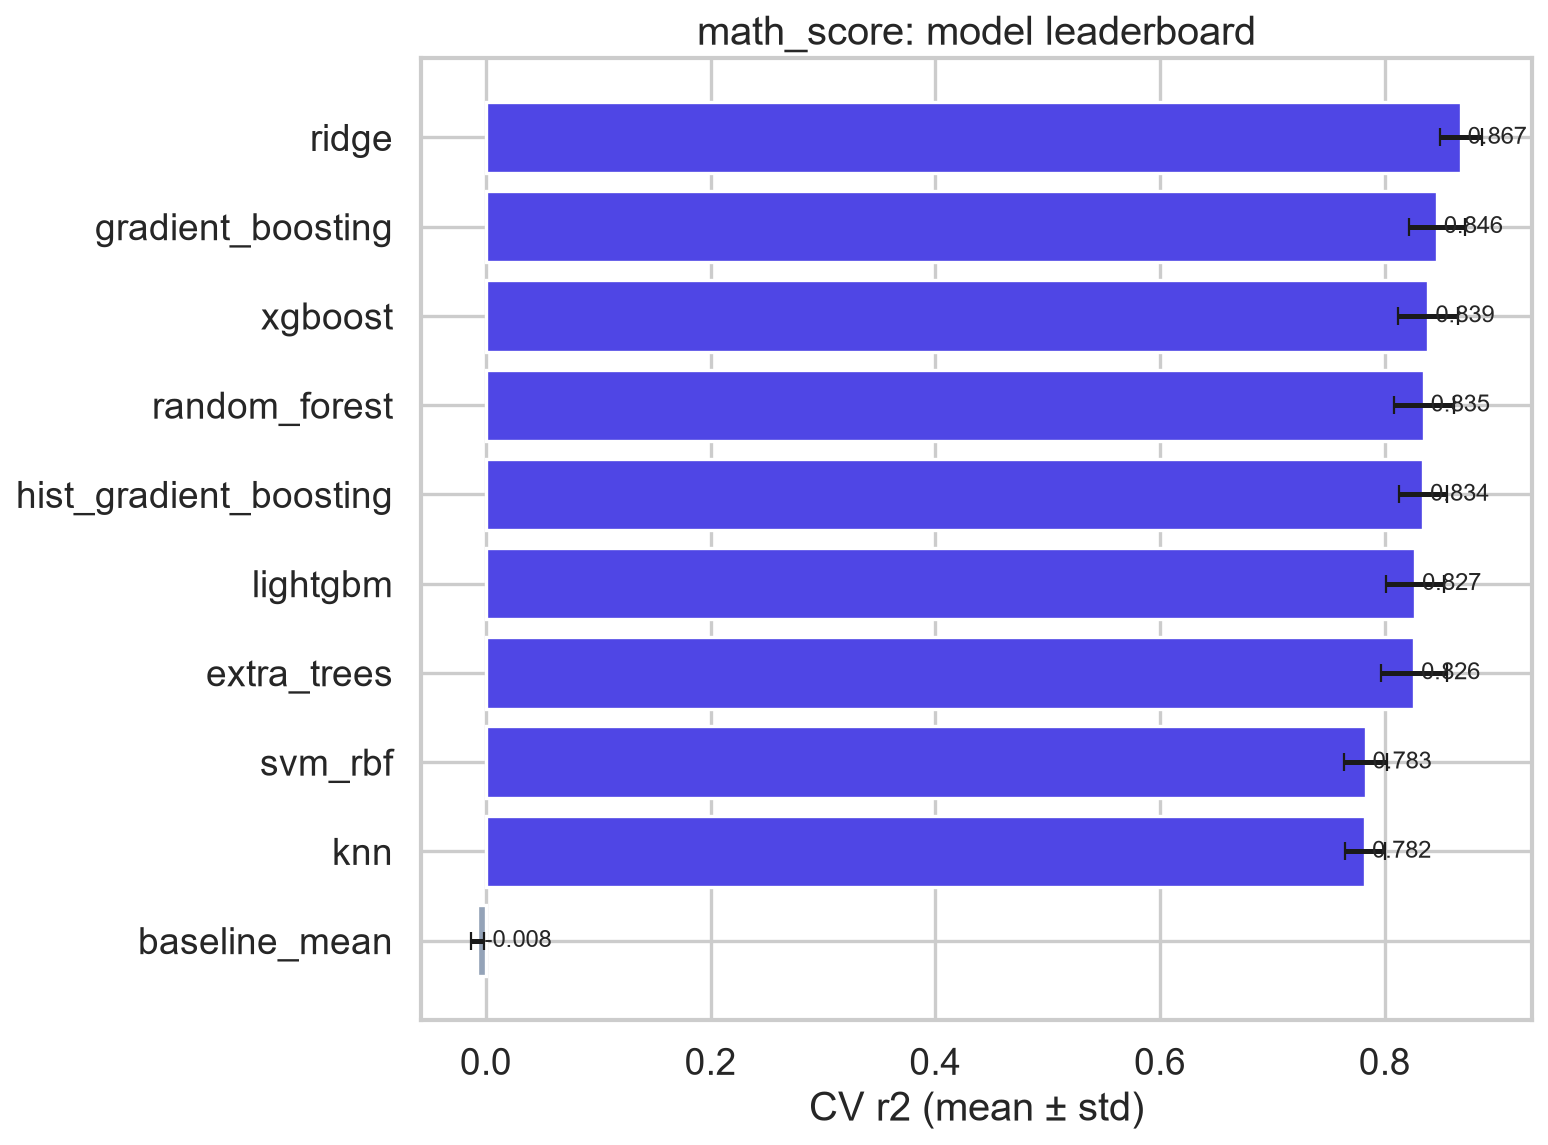

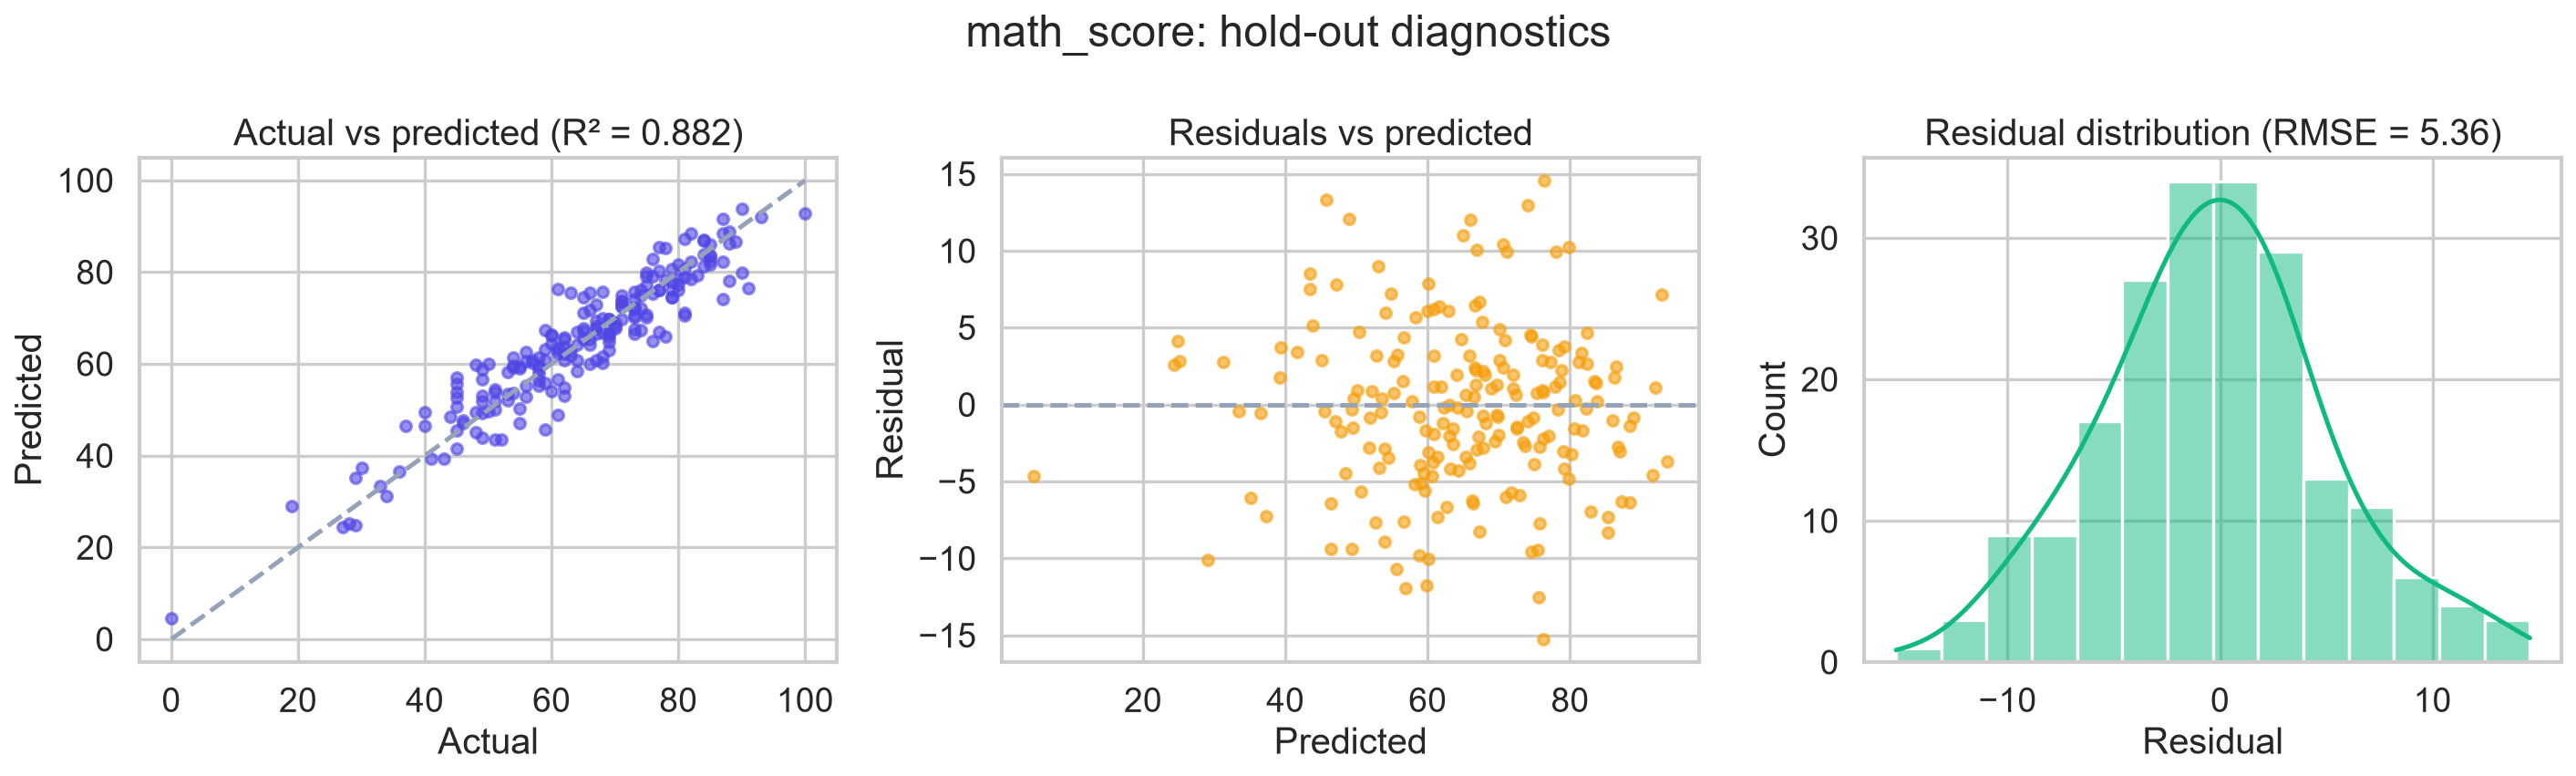

### performance_level: hist_gradient_boosting

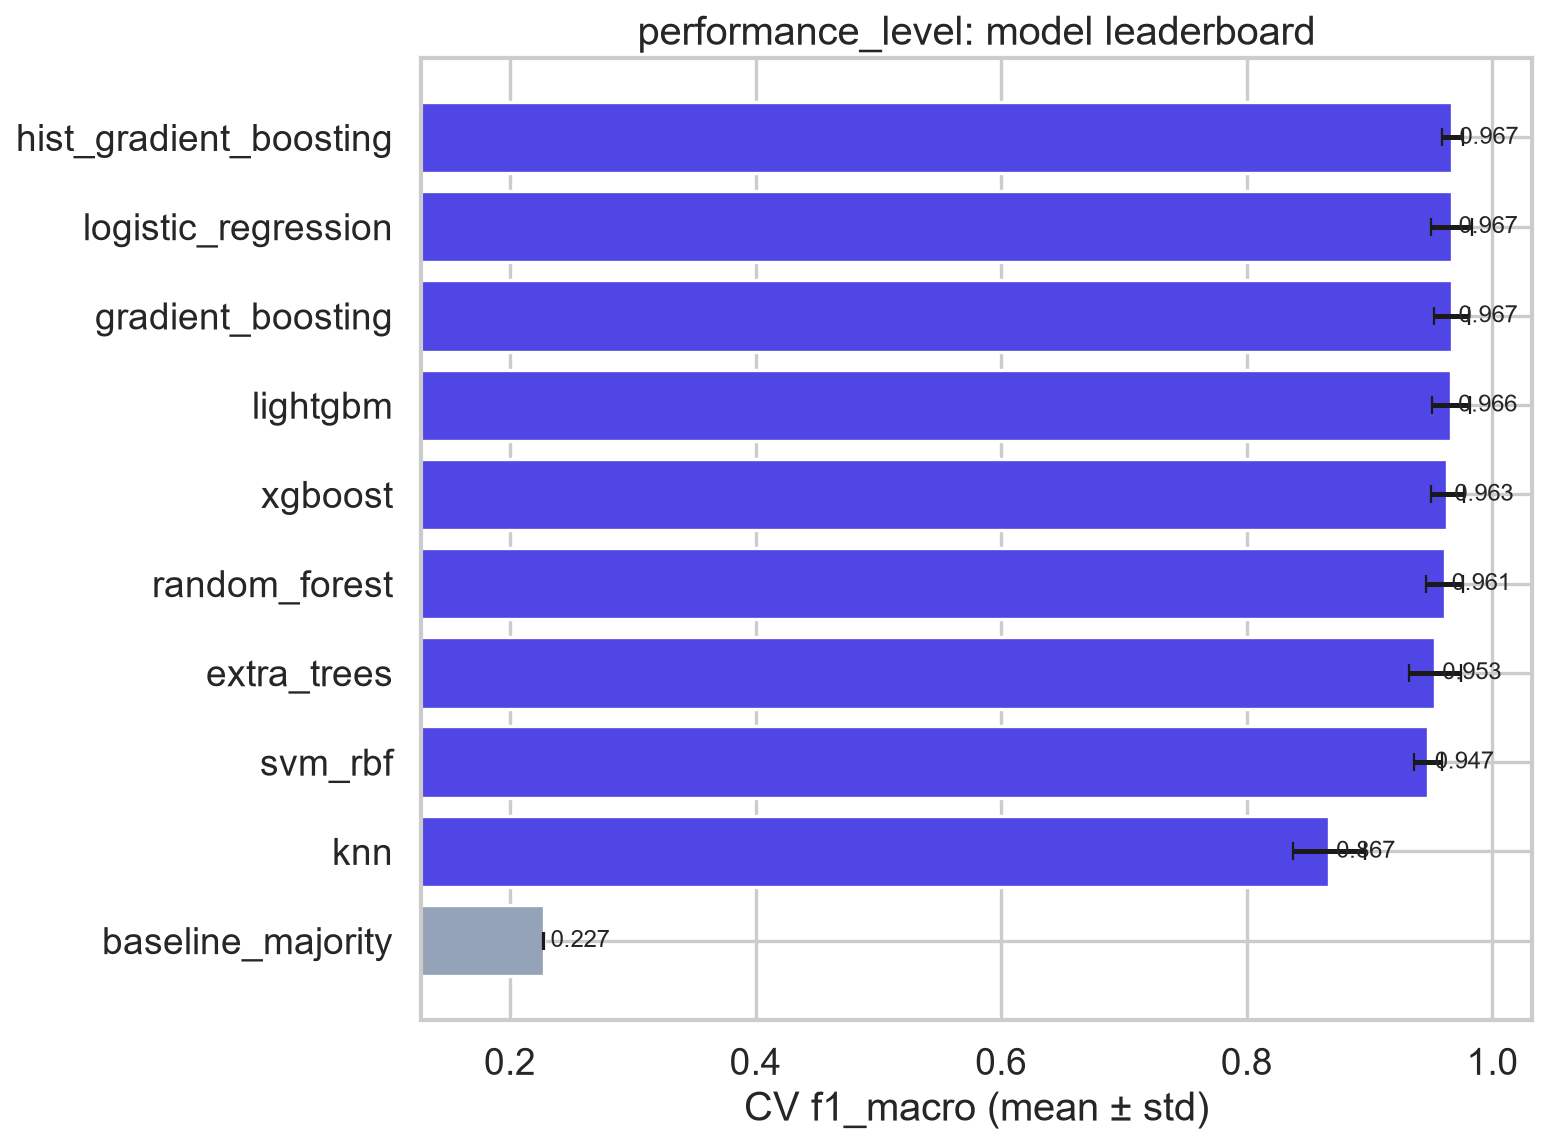

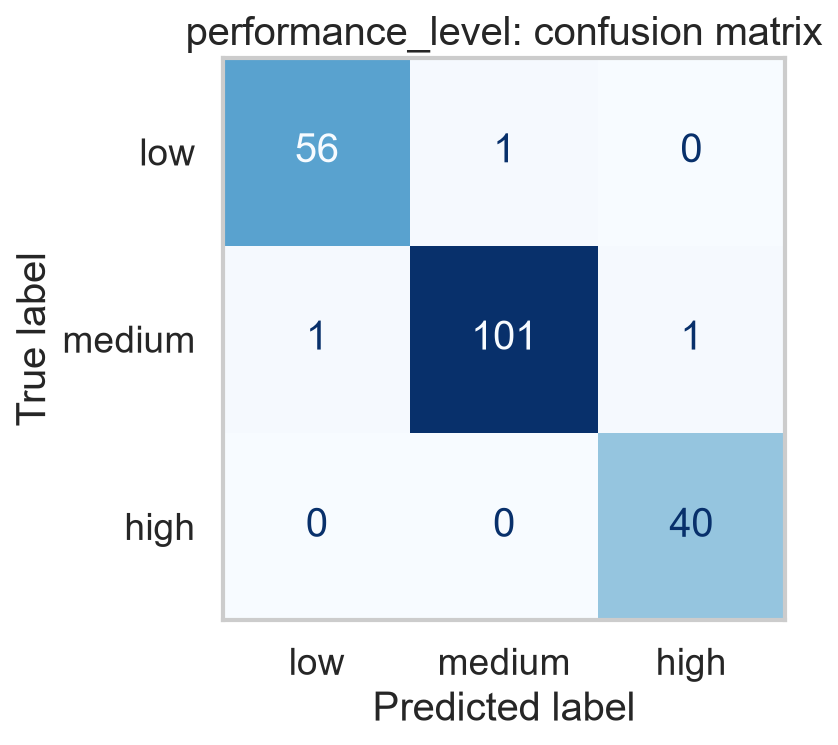

In [8]:
for t in ('at_risk','math_score','performance_level'):
    try: m = reg.load(t)
    except FileNotFoundError: continue
    display(Markdown(f'### {t}: {m.metadata.model_name}'))
    for key in ('leaderboard','roc_pr','diagnostics','confusion'):
        p = m.metadata.figures.get(key)
        if p and Path(p).exists(): display(Image(p, width=800))

## 4. The leakage case study
The original coursework predicted `performance_level` from the three scores. Because the label is defined as a threshold on their average, any model just re-learns the cut-offs, which gives close to 100% accuracy. The number is real but it tells you nothing. The at-risk task (background only) is the formulation that means something.

In [9]:
try:
    m = reg.load('performance_level'); print(m.task.leakage_note); print(); print(np.array(m.metadata.test_metrics['confusion_matrix']))
except FileNotFoundError: print('performance_level model not trained yet')

The target is a deterministic function of the three score inputs (average < 60 -> low, < 80 -> medium, else high). Near-perfect accuracy is therefore expected and says nothing about generalisation. The task is kept for continuity with the original report and as a leakage case study. See the 'at_risk' task for the background-only formulation.

[[ 56   1   0]
 [  1 101   1]
 [  0   0  40]]
